# MiniVersionRDA — Clean, Traceable Version

This notebook is a teaching-scale mirror of the UTAS Research Degree Assistant.

It can be use it in **two ways**:

1. **Run one cell at a time** and inspect every intermediate result.
2. Call **`ask(question)`** and see the whole pipeline sequentially.

Canonical questions:
- `Who is Quan Bai?` → graph route
- `What English score do I need for a PhD?` → document retrieval
- `Find funded international ICT PhD projects related to machine learning.` → hybrid graph + retrieval

## Key idea: processed data, not raw PDF at query time

This mini version starts from structured records and saves them as JSON. A light cleaning step normalises whitespace.

**JSON corpus** means the collection of processed JSON records that retrieval searches. It is not a SQL database.

In [2]:
###Installing Required Libraries
%pip install -q rdflib rank-bm25 sentence-transformers scikit-learn networkx matplotlib requests

Note: you may need to restart the kernel to use updated packages.


In [3]:
###Importing Libraries and Preparing Folders
import json, re, requests
from pathlib import Path
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from rank_bm25 import BM25Okapi
from rdflib import Graph, Namespace, Literal, RDF, RDFS
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

processed_dir = Path('mini_data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)
print('Working folder:', processed_dir.resolve())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working folder: /Users/hosna/Documents/UTAS_research_guide_Agent/utas-research-degree-assistant/mini_version/mini_data/processed


In [4]:
###Creating and Cleaning the Mini Knowledge Records

def clean_text(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

supervisors = [
    {
        'supervisor_id':'S001','name':'Quan Bai','title':'Doctor',
        'school':'School of Information and Communication Technology',
        'research_fields':['Artificial intelligence','Autonomous agents and multiagent systems','Recommender systems','Data mining and knowledge discovery'],
        'source_url':'https://discover.utas.edu.au/api/users/Quan.Bai'
    },
    {
        'supervisor_id':'S002','name':'Shuxiang Xu','title':'Doctor',
        'school':'University of Tasmania',
        'research_fields':['Machine learning','Deep learning','Neural networks','Computer vision'],
        'source_url':'https://discover.utas.edu.au/api/users/Shuxiang.Xu'
    },
    {
        'supervisor_id':'S003','name':'Soonja Yeom','title':'Doctor',
        'school':'School of Information and Communication Technology',
        'research_fields':['Human-centred computing','Artificial intelligence','Learning technologies'],
        'source_url':'https://discover.utas.edu.au/'
    }
]

projects = [
    {
        'project_id':'P001','title':'Machine Learning for Intelligent Decision Support','supervisor':'Quan Bai',
        'degree_type':['PhD'],'student_type':['Domestic','International'],'location':'Hobart','funding_status':'funded',
        'application_status':'Applications open','research_category':'Information and Communication Technology',
        'description':'This project investigates machine learning, autonomous agents, and data-driven decision support.',
        'source_url':'https://www.utas.edu.au/research/degrees/available-projects'
    },
    {
        'project_id':'P002','title':'Multimodal Deep Learning for Cybersecurity','supervisor':'Shuxiang Xu',
        'degree_type':['PhD','Master by Research'],'student_type':['Domestic','International'],'location':'Launceston','funding_status':'funded',
        'application_status':'Applications open','research_category':'Information and Communication Technology',
        'description':'This project applies deep learning and machine learning to multimodal cybersecurity data.',
        'source_url':'https://www.utas.edu.au/research/degrees/available-projects'
    },
    {
        'project_id':'P003','title':'Human-Centred AI Feedback for Learning','supervisor':'Soonja Yeom',
        'degree_type':['PhD'],'student_type':['Domestic','International'],'location':'Hobart','funding_status':'unfunded',
        'application_status':'Applications open','research_category':'Information and Communication Technology',
        'description':'This project studies adaptive and dialogic AI feedback for university learning.',
        'source_url':'https://www.utas.edu.au/research/degrees/available-projects'
    },
    {
        'project_id':'P004','title':'Marine Ecosystem Modelling','supervisor':'Quan Bai',
        'degree_type':['PhD'],'student_type':['Domestic','International'],'location':'Hobart','funding_status':'funded',
        'application_status':'Applications open','research_category':'Natural Sciences',
        'description':'This project develops computational models for marine ecosystems.',
        'source_url':'https://www.utas.edu.au/research/degrees/available-projects'
    }
]

general_chunks = [
    {'chunk_id':'G001','source':'HDR Entry Requirements','text':'Applicants for a PhD or other research degree must satisfy the academic entry requirements for the chosen program.','source_url':'https://www.utas.edu.au/research/degrees'},
    {'chunk_id':'G002','source':'English Language Requirements','text':"Applicants for a PhD must satisfy the University's English language requirements before commencing the research degree. This mini teaching snapshot does not contain an exact numerical score.",'source_url':'https://www.utas.edu.au/study/apply/admission-requirements/english-language-requirements'},
    {'chunk_id':'G003','source':'Research Degree Funding','text':'Research project funding and scholarship conditions vary by project and should be checked against official project information.','source_url':'https://www.utas.edu.au/research/degrees'}
]

for group in (supervisors, projects, general_chunks):
    for record in group:
        for key, value in list(record.items()):
            if isinstance(value, str): record[key] = clean_text(value)
            elif isinstance(value, list): record[key] = [clean_text(x) for x in value]

print('Supervisors:', len(supervisors), 'Projects:', len(projects), 'General chunks:', len(general_chunks))

Supervisors: 3 Projects: 4 General chunks: 3


In [5]:
###Saving the JSON Corpus
for filename, records in {
    'supervisor_documents.json': supervisors,
    'project_documents.json': projects,
    'general_chunks.json': general_chunks,
}.items():
    with open(processed_dir/filename, 'w', encoding='utf-8') as f:
        json.dump(records, f, indent=2, ensure_ascii=False)
    print('Saved:', processed_dir/filename)

Saved: mini_data/processed/supervisor_documents.json
Saved: mini_data/processed/project_documents.json
Saved: mini_data/processed/general_chunks.json


## Building the knowledge graph

The graph is created from the structured records by converting facts into RDF triples:

**Subject → Predicate → Object**

Example: `P001 → supervisedBy → Quan Bai`.

In [6]:
###Building the RDF Knowledge Graph

graph = Graph()
UTAS = Namespace('https://example.org/utas-research/')
graph.bind('utas', UTAS)
graph.bind('rdfs', RDFS)

def uri_safe(text):
    return re.sub(r'[^A-Za-z0-9_]+', '_', text.strip()).strip('_')

supervisor_nodes = {}
for s in supervisors:
    sn = UTAS['supervisor_' + uri_safe(s['name'])]
    supervisor_nodes[s['name']] = sn
    graph.add((sn, RDF.type, UTAS.Supervisor))
    graph.add((sn, RDFS.label, Literal(s['name'])))
    graph.add((sn, UTAS.title, Literal(s['title'])))
    graph.add((sn, UTAS.school, Literal(s['school'])))
    graph.add((sn, UTAS.sourceUrl, Literal(s['source_url'])))
    for field in s['research_fields']:
        fn = UTAS['field_' + uri_safe(field)]
        graph.add((fn, RDF.type, UTAS.ResearchField))
        graph.add((fn, RDFS.label, Literal(field)))
        graph.add((sn, UTAS.hasResearchField, fn))

for p in projects:
    pn = UTAS[p['project_id']]
    sn = supervisor_nodes[p['supervisor']]
    cn = UTAS['category_' + uri_safe(p['research_category'])]
    graph.add((pn, RDF.type, UTAS.ResearchProject))
    graph.add((pn, UTAS.projectId, Literal(p['project_id'])))
    graph.add((pn, UTAS.title, Literal(p['title'])))
    graph.add((pn, UTAS.description, Literal(p['description'])))
    graph.add((pn, UTAS.location, Literal(p['location'])))
    graph.add((pn, UTAS.fundingStatus, Literal(p['funding_status'])))
    graph.add((pn, UTAS.applicationStatus, Literal(p['application_status'])))
    graph.add((pn, UTAS.sourceUrl, Literal(p['source_url'])))
    graph.add((pn, UTAS.supervisedBy, sn))
    graph.add((cn, RDF.type, UTAS.ResearchCategory))
    graph.add((cn, RDFS.label, Literal(p['research_category'])))
    graph.add((pn, UTAS.hasResearchCategory, cn))
    for degree in p['degree_type']:
        graph.add((pn, UTAS.degreeType, Literal(degree)))
    for student_type in p['student_type']:
        graph.add((pn, UTAS.studentType, Literal(student_type)))

graph.serialize(processed_dir/'utas_research_graph.ttl', format='turtle')
print('RDF triples:', len(graph))
print('Saved:', processed_dir/'utas_research_graph.ttl')

RDF triples: 103
Saved: mini_data/processed/utas_research_graph.ttl


In [7]:
###Inspecting Example RDF Triples
for i, triple in enumerate(graph):
    print(triple)
    if i >= 9: break

(rdflib.term.URIRef('https://example.org/utas-research/P002'), rdflib.term.URIRef('https://example.org/utas-research/supervisedBy'), rdflib.term.URIRef('https://example.org/utas-research/supervisor_Shuxiang_Xu'))
(rdflib.term.URIRef('https://example.org/utas-research/P004'), rdflib.term.URIRef('https://example.org/utas-research/title'), rdflib.term.Literal('Marine Ecosystem Modelling'))
(rdflib.term.URIRef('https://example.org/utas-research/supervisor_Shuxiang_Xu'), rdflib.term.URIRef('https://example.org/utas-research/sourceUrl'), rdflib.term.Literal('https://discover.utas.edu.au/api/users/Shuxiang.Xu'))
(rdflib.term.URIRef('https://example.org/utas-research/P004'), rdflib.term.URIRef('https://example.org/utas-research/applicationStatus'), rdflib.term.Literal('Applications open'))
(rdflib.term.URIRef('https://example.org/utas-research/P003'), rdflib.term.URIRef('https://example.org/utas-research/description'), rdflib.term.Literal('This project studies adaptive and dialogic AI feedback

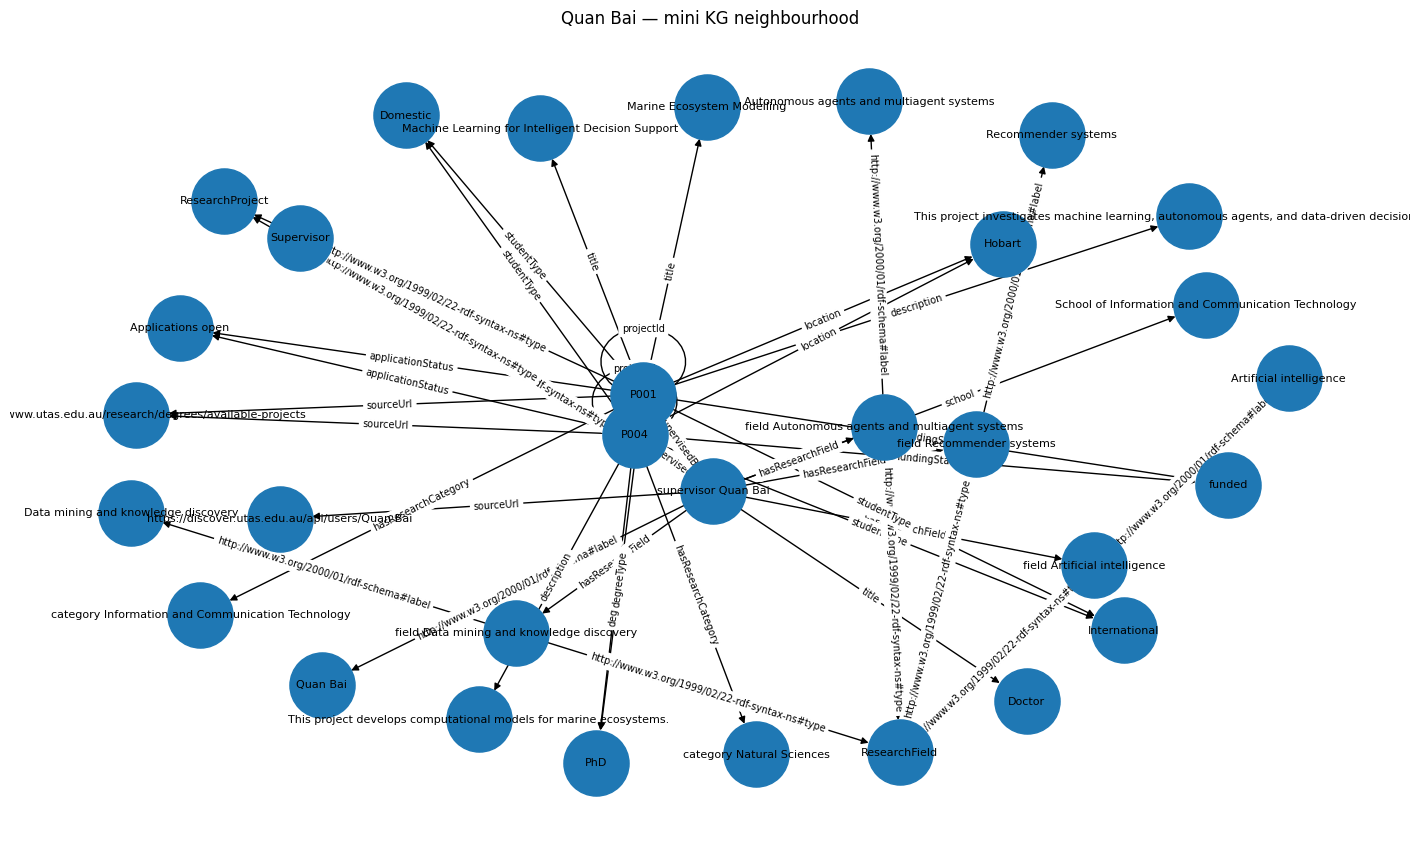

In [18]:
###Visualizing a Relevant Knowledge-Graph Subgraph


def short_label(value):
    text = str(value)
    if text.startswith(str(UTAS)): text = text.replace(str(UTAS), '')
    return text.replace('_', ' ')

def find_supervisor_node(name):
    for node in graph.subjects(RDF.type, UTAS.Supervisor):
        labels = [str(x) for x in graph.objects(node, RDFS.label)]
        if any(x.casefold()==name.casefold() for x in labels): return node

def show_subgraph(seed_nodes, title='Relevant KG subgraph'):
    seed_nodes=set(seed_nodes)
    triples=[]
    for s,p,o in graph:
        if s in seed_nodes or o in seed_nodes: triples.append((s,p,o))
    discovered=set(seed_nodes)
    for s,_,o in triples:
        discovered.add(s)
        if str(o).startswith(str(UTAS)): discovered.add(o)
    for s,p,o in graph:
        if s in discovered and (s,p,o) not in triples: triples.append((s,p,o))
    G=nx.DiGraph()
    for s,p,o in triples:
        G.add_edge(short_label(s), short_label(o), label=short_label(p))
    plt.figure(figsize=(14,8))
    pos=nx.spring_layout(G, seed=42)
    nx.draw(G,pos,with_labels=True,node_size=2200,font_size=8,arrows=True)
    nx.draw_networkx_edge_labels(G,pos,edge_labels=nx.get_edge_attributes(G,'label'),font_size=7)
    plt.title(title); plt.axis('off'); plt.show()

show_subgraph([find_supervisor_node('Quan Bai')], 'Quan Bai — mini KG neighbourhood')

## Preparing document retrieval

The retriever searches processed JSON-derived text records. It does not reopen a PDF for each question.

In [19]:
###Creating Searchable Documents and Retrieval Resources
retrieval_documents=[]
for g in general_chunks:
    retrieval_documents.append({'document_id':g['chunk_id'],'scope':'general','source':g['source'],'source_url':g['source_url'],'project_id':None,'text':g['text']})
for p in projects:
    text=clean_text(f"{p['title']} {p['description']} {' '.join(p['degree_type'])} {' '.join(p['student_type'])} {p['funding_status']} {p['location']} {p['research_category']} {p['supervisor']}")
    retrieval_documents.append({'document_id':p['project_id'],'scope':'projects','source':p['title'],'source_url':p['source_url'],'project_id':p['project_id'],'text':text})
for s in supervisors:
    text=clean_text(f"{s['title']} {s['name']} {s['school']} {' '.join(s['research_fields'])}")
    retrieval_documents.append({'document_id':s['supervisor_id'],'scope':'supervisors','source':s['name'],'source_url':s['source_url'],'project_id':None,'text':text})

def tokens(text): return re.findall(r'[A-Za-z0-9]+', text.lower())

bm25 = BM25Okapi([tokens(d['text']) for d in retrieval_documents])
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
semantic_embeddings = embedding_model.encode([d['text'] for d in retrieval_documents], show_progress_bar=False)
np.save(processed_dir/'semantic_embeddings.npy', semantic_embeddings)
print('Searchable records:', len(retrieval_documents), 'Embedding shape:', semantic_embeddings.shape)

Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 6528.54it/s]


Searchable records: 10 Embedding shape: (10, 384)


In [20]:
###Creating Traceable BM25 + MiniLM + RRF Retrieval

def rrf(rank,k=60): return 1/(k+rank)

def hybrid_retrieve(question, scope=None, candidate_project_ids=None, top_k=5):
    idx=[]
    for i,d in enumerate(retrieval_documents):
        if scope and d['scope']!=scope: continue
        if candidate_project_ids is not None and d['project_id'] not in candidate_project_ids: continue
        idx.append(i)
    bm25_scores=bm25.get_scores(tokens(question))
    qvec=embedding_model.encode([question], show_progress_bar=False)
    sem_scores=cosine_similarity(qvec, semantic_embeddings)[0]
    br=sorted(idx,key=lambda i:bm25_scores[i],reverse=True)
    sr=sorted(idx,key=lambda i:sem_scores[i],reverse=True)
    combined={i:0.0 for i in idx}
    for rank,i in enumerate(br,1): combined[i]+=rrf(rank)
    for rank,i in enumerate(sr,1): combined[i]+=rrf(rank)
    hr=sorted(idx,key=lambda i:combined[i],reverse=True)
    results=[]
    for h_rank,i in enumerate(hr[:top_k],1):
        d=dict(retrieval_documents[i]); d.update({'hybrid_rank':h_rank,'bm25_rank':br.index(i)+1,'semantic_rank':sr.index(i)+1,'bm25_score':float(bm25_scores[i]),'semantic_score':float(sem_scores[i]),'rrf_score':float(combined[i])}); results.append(d)
    trace={
        'question':question,'scope':scope,'candidate_project_ids':sorted(candidate_project_ids) if candidate_project_ids else None,
        'bm25_query_tokens':tokens(question),
        'bm25_ranking':[{'rank':r,'id':retrieval_documents[i]['document_id'],'source':retrieval_documents[i]['source'],'score':float(bm25_scores[i])} for r,i in enumerate(br,1)],
        'semantic_ranking':[{'rank':r,'id':retrieval_documents[i]['document_id'],'source':retrieval_documents[i]['source'],'score':float(sem_scores[i])} for r,i in enumerate(sr,1)],
        'rrf_results':results
    }
    return results, trace

## Controlled graph operations

These operations are approved at design time because they correspond to supported intents, use existing graph relationships, and have implemented read-only query functions. The LLM may select from the allowlist but may not invent executable graph operations.

In [21]:
###Defining the Approved Graph-Operation Allowlist
ALLOWED_GRAPH_OPERATIONS={'supervisor_by_name','projects_by_supervisor','multi_constraint_projects'}
print(ALLOWED_GRAPH_OPERATIONS)

{'multi_constraint_projects', 'projects_by_supervisor', 'supervisor_by_name'}


In [22]:
###Creating the Predefined Graph Query Functions

def get_supervisor_profile(graph, supervisor_name):
    sparql='''
PREFIX utas: <https://example.org/utas-research/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?supervisor ?name ?title ?school ?field ?projectId ?projectTitle ?sourceUrl
WHERE {
  ?supervisor rdf:type utas:Supervisor ; rdfs:label ?name .
  FILTER(LCASE(STR(?name)) = LCASE(STR(?wantedName)))
  OPTIONAL { ?supervisor utas:title ?title }
  OPTIONAL { ?supervisor utas:school ?school }
  OPTIONAL { ?supervisor utas:sourceUrl ?sourceUrl }
  OPTIONAL { ?supervisor utas:hasResearchField ?fieldNode . ?fieldNode rdfs:label ?field . }
  OPTIONAL { ?project utas:supervisedBy ?supervisor ; utas:projectId ?projectId ; utas:title ?projectTitle . }
}
ORDER BY ?field ?projectId
'''
    bindings={'wantedName':Literal(supervisor_name)}
    rows=list(graph.query(sparql, initBindings=bindings))
    if not rows: return None,sparql,bindings
    profile={
        'name':str(rows[0].name),'title':str(rows[0].title) if rows[0].title else None,'school':str(rows[0].school) if rows[0].school else None,
        'research_fields':sorted({str(r.field) for r in rows if r.field}),
        'projects':sorted({(str(r.projectId),str(r.projectTitle)) for r in rows if r.projectId}),
        'source_url':str(rows[0].sourceUrl) if rows[0].sourceUrl else None
    }
    return profile,sparql,bindings

def get_projects_by_constraints(graph, degree_type=None, student_type=None, funding_status=None, research_category=None):
    patterns=[]; bindings={}
    if degree_type:
        patterns += ['?project utas:degreeType ?degreeType .','FILTER(LCASE(STR(?degreeType)) = LCASE(STR(?wantedDegree)))']; bindings['wantedDegree']=Literal(degree_type)
    if student_type:
        patterns += ['?project utas:studentType ?studentType .','FILTER(LCASE(STR(?studentType)) = LCASE(STR(?wantedStudentType)))']; bindings['wantedStudentType']=Literal(student_type)
    if funding_status:
        patterns += ['?project utas:fundingStatus ?fundingStatus .','FILTER(LCASE(STR(?fundingStatus)) = LCASE(STR(?wantedFunding)))']; bindings['wantedFunding']=Literal(funding_status)
    if research_category:
        patterns += ['?project utas:hasResearchCategory ?categoryNode .','?categoryNode rdfs:label ?categoryLabel .','FILTER(LCASE(STR(?categoryLabel)) = LCASE(STR(?wantedCategory)))']; bindings['wantedCategory']=Literal(research_category)
    dyn='\n  '.join(patterns)
    sparql=f'''
PREFIX utas: <https://example.org/utas-research/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT DISTINCT ?project ?projectId ?title ?description ?sourceUrl
WHERE {{
  ?project rdf:type utas:ResearchProject ; utas:projectId ?projectId ; utas:title ?title .
  OPTIONAL {{ ?project utas:description ?description }}
  OPTIONAL {{ ?project utas:sourceUrl ?sourceUrl }}
  {dyn}
}}
ORDER BY ?projectId
'''
    rows=list(graph.query(sparql, initBindings=bindings))
    result=[{'project_uri':str(r.project),'project_id':str(r.projectId),'title':str(r.title),'description':str(r.description) if r.description else None,'source_url':str(r.sourceUrl) if r.sourceUrl else None} for r in rows]
    return result,sparql,bindings

def execute_graph_operation(plan):
    op=plan.get('graph_operation')
    if op not in ALLOWED_GRAPH_OPERATIONS: raise ValueError(f'Unsupported graph operation: {op}')
    if op=='supervisor_by_name':
        result,sparql,bindings=get_supervisor_profile(graph, plan['supervisor']); fn='get_supervisor_profile'
    elif op=='multi_constraint_projects':
        result,sparql,bindings=get_projects_by_constraints(graph,plan.get('degree_type'),plan.get('student_type'),plan.get('funding_status'),plan.get('research_category')); fn='get_projects_by_constraints'
    else:
        raise NotImplementedError('projects_by_supervisor is intentionally omitted from the three canonical demos')
    return {'operation':op,'function_name':fn,'sparql':sparql.strip(),'bindings':{k:str(v) for k,v in bindings.items()},'result':result}

In [23]:
###Creating Qwen-Based Interpretation with a Deterministic Fallback

def planner_prompt(question):
    return f'''
You are the routing component of a mini research degree assistant.
Do NOT answer the user. Return one structured JSON plan.

METHOD RULES:
- graph: exact entity/profile/relationship lookup
- retrieval: descriptive information stored in text documents
- hybrid_graph: structured project constraints + semantic topic ranking

GRAPH OPERATIONS:
- supervisor_by_name
- multi_constraint_projects

Return fields: method, scope, search_query, degree_type, student_type, funding_status, research_category, supervisor, graph_operation, intent, confidence.
Use null where not applicable.
Canonical ICT value: Information and Communication Technology

Examples:
Who is Quan Bai? -> graph, supervisors, supervisor_by_name, supervisor=Quan Bai
What English score do I need for a PhD? -> retrieval, general
Find funded international ICT PhD projects related to machine learning. -> hybrid_graph, projects, multi_constraint_projects, search_query=machine learning, degree_type=PhD, student_type=International, funding_status=funded, research_category=Information and Communication Technology

USER QUESTION: {question}
Return ONLY valid JSON.
'''.strip()

def ollama_available():
    try: return requests.get('http://localhost:11434/api/tags', timeout=2).ok
    except Exception: return False

def fallback_plan(question):
    q=question.casefold()
    if 'quan bai' in q and ('who is' in q or 'profile' in q or 'tell me about' in q):
        return {'method':'graph','scope':'supervisors','search_query':'Quan Bai','degree_type':None,'student_type':None,'funding_status':None,'research_category':None,'supervisor':'Quan Bai','graph_operation':'supervisor_by_name','intent':'supervisor_profile_lookup','confidence':0.9}
    if 'english' in q and 'phd' in q:
        return {'method':'retrieval','scope':'general','search_query':'PhD English language requirements','degree_type':None,'student_type':None,'funding_status':None,'research_category':None,'supervisor':None,'graph_operation':None,'intent':'english_requirement_lookup','confidence':0.85}
    if 'machine learning' in q and 'funded' in q and 'international' in q and ('ict' in q or 'information and communication technology' in q) and 'phd' in q:
        return {'method':'hybrid_graph','scope':'projects','search_query':'machine learning','degree_type':'PhD','student_type':'International','funding_status':'funded','research_category':'Information and Communication Technology','supervisor':None,'graph_operation':'multi_constraint_projects','intent':'constrained_project_discovery','confidence':0.9}
    return {'method':'retrieval','scope':'general','search_query':question,'degree_type':None,'student_type':None,'funding_status':None,'research_category':None,'supervisor':None,'graph_operation':None,'intent':'general_lookup','confidence':0.5}

def interpret_question(question, force_fallback=False):
    prompt=planner_prompt(question); error=None
    try:
        if force_fallback or not ollama_available(): raise RuntimeError('Using deterministic fallback')
        r=requests.post('http://localhost:11434/api/generate',json={'model':'qwen3:1.7b','prompt':prompt,'format':'json','stream':False},timeout=120); r.raise_for_status(); plan=json.loads(r.json()['response']); plan['planner_method']='qwen'
    except Exception as e:
        error=str(e); plan=fallback_plan(question); plan['planner_method']='deterministic_fallback'
    return {'question':question,'prompt':prompt,'plan':plan,'error':error}

In [24]:
###Executing the Chosen Search Route

def execute_route(question, plan):
    if plan['method']=='graph':
        gt=execute_graph_operation(plan)
        return {'route':'graph','graph_trace':gt,'retrieval_trace':None,'raw_evidence':gt['result']}
    if plan['method']=='retrieval':
        results,rt=hybrid_retrieve(plan['search_query'],scope=plan['scope'],top_k=3)
        return {'route':'retrieval','graph_trace':None,'retrieval_trace':rt,'raw_evidence':results}
    if plan['method']=='hybrid_graph':
        gt=execute_graph_operation(plan); ids={x['project_id'] for x in gt['result']}
        results,rt=hybrid_retrieve(plan['search_query'],scope='projects',candidate_project_ids=ids,top_k=5)
        return {'route':'hybrid_graph','graph_trace':gt,'candidate_project_ids':sorted(ids),'retrieval_trace':rt,'raw_evidence':results}
    raise ValueError(plan['method'])

In [25]:
###Preparing Evidence and Generating a Grounded Answer
STOPWORDS={'a','an','the','is','are','who','what','which','do','does','i','me','my','for','to','of','in','on','and','or','with','need'}

def prepare_evidence(route_output):
    if route_output['route']=='graph':
        r=route_output['raw_evidence']
        return [] if not r else [{'source_id':'S1','source_type':'knowledge_graph','source':r.get('name','Knowledge graph'),'source_url':r.get('source_url'),'text':json.dumps(r,ensure_ascii=False)}]
    return [{'source_id':f'S{i}','source_type':'retrieved_text','source':r['source'],'source_url':r['source_url'],'project_id':r['project_id'],'text':r['text'],'bm25_score':r['bm25_score'],'semantic_score':r['semantic_score'],'rrf_score':r['rrf_score']} for i,r in enumerate(route_output['raw_evidence'],1)]

def evidence_guard(question,evidence):
    qt={x for x in re.findall(r'[a-z0-9]+',question.casefold()) if x not in STOPWORDS and len(x)>1}
    et={x for x in re.findall(r'[a-z0-9]+',' '.join(e['text'] for e in evidence).casefold()) if x not in STOPWORDS and len(x)>1}
    supported=sorted(qt & et); threshold=min(2,max(1,len(qt)))
    return {'passed':bool(evidence) and len(supported)>=threshold,'question_terms':sorted(qt),'supported_terms':supported,'threshold':threshold}

def answer_prompt(question,evidence):
    ev='\n\n'.join(f"[{e['source_id']}] Source: {e['source']}\nContent: {e['text']}\nURL: {e['source_url']}" for e in evidence)
    return f"Answer using ONLY the evidence below. Do not invent information. Cite [S1], [S2], etc.\n\nQUESTION: {question}\n\nEVIDENCE:\n{ev}\n\nANSWER:"

def generate_answer(question,evidence):
    guard=evidence_guard(question,evidence); prompt=answer_prompt(question,evidence)
    if not guard['passed']: return {'guard':guard,'prompt':prompt,'method':'insufficient_evidence','answer':'The available evidence is insufficient to answer this question.'}
    try:
        if not ollama_available(): raise RuntimeError('Ollama unavailable')
        r=requests.post('http://localhost:11434/api/generate',json={'model':'qwen3:1.7b','prompt':prompt,'stream':False},timeout=120); r.raise_for_status(); ans=r.json()['response']; method='qwen'
    except Exception:
        if 'who is quan bai' in question.casefold():
            d=json.loads(evidence[0]['text']); ans=f"{d['title']} {d['name']} is associated with {d['school']}. The mini graph lists research fields including {', '.join(d['research_fields'][:4])}. [S1]"
        elif 'english' in question.casefold(): ans="The mini snapshot says PhD applicants must satisfy the University's English language requirements, but it does not contain an exact numerical score. [S1]"
        else: ans='Relevant graph-filtered project matches: ' + '; '.join(e['source'] for e in evidence)
        method='grounded_fallback'
    return {'guard':guard,'prompt':prompt,'method':method,'answer':ans}

In [26]:
###Creating Visible Trace Helpers

def pj(title,obj):
    print(f'\n{title}\n'+'-'*len(title)); print(json.dumps(obj,indent=2,ensure_ascii=False,default=str))

def show_graph_trace(gt):
    pj('GRAPH INPUT',{'operation':gt['operation'],'function_called':gt['function_name'],'bindings':gt['bindings']})
    print('\nEXACT CONTROLLED SPARQL\n-----------------------\n'+gt['sparql'])
    pj('GRAPH RESULT',gt['result'])

def show_retrieval_trace(rt):
    pj('RETRIEVAL INPUT',{'scope':rt['scope'],'candidate_project_ids':rt['candidate_project_ids'],'bm25_query_tokens':rt['bm25_query_tokens']})
    pj('BM25 RANKING',rt['bm25_ranking']); pj('MINILM SEMANTIC RANKING',rt['semantic_ranking']); pj('RRF HYBRID RESULTS',rt['rrf_results'])

# Manual cell-by-cell demo 1 — `Who is Quan Bai?`

In [27]:
question_1='Who is Quan Bai?'
trace_plan_1=interpret_question(question_1)
pj('STRUCTURED PLAN',trace_plan_1['plan'])


STRUCTURED PLAN
---------------
{
  "method": "graph",
  "scope": "supervisors",
  "search_query": "Quan Bai",
  "degree_type": null,
  "student_type": null,
  "funding_status": null,
  "research_category": "Information and Communication Technology",
  "supervisor": "Quan Bai",
  "graph_operation": "supervisor_by_name",
  "intent": "identification",
  "confidence": 1.0,
  "planner_method": "qwen"
}


In [28]:
route_1=execute_route(question_1,trace_plan_1['plan'])
show_graph_trace(route_1['graph_trace'])


GRAPH INPUT
-----------
{
  "operation": "supervisor_by_name",
  "function_called": "get_supervisor_profile",
  "bindings": {
    "wantedName": "Quan Bai"
  }
}

EXACT CONTROLLED SPARQL
-----------------------
PREFIX utas: <https://example.org/utas-research/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?supervisor ?name ?title ?school ?field ?projectId ?projectTitle ?sourceUrl
WHERE {
  ?supervisor rdf:type utas:Supervisor ; rdfs:label ?name .
  FILTER(LCASE(STR(?name)) = LCASE(STR(?wantedName)))
  OPTIONAL { ?supervisor utas:title ?title }
  OPTIONAL { ?supervisor utas:school ?school }
  OPTIONAL { ?supervisor utas:sourceUrl ?sourceUrl }
  OPTIONAL { ?supervisor utas:hasResearchField ?fieldNode . ?fieldNode rdfs:label ?field . }
  OPTIONAL { ?project utas:supervisedBy ?supervisor ; utas:projectId ?projectId ; utas:title ?projectTitle . }
}
ORDER BY ?field ?projectId

GRAPH RESULT
------------
{
  "name": "Quan 

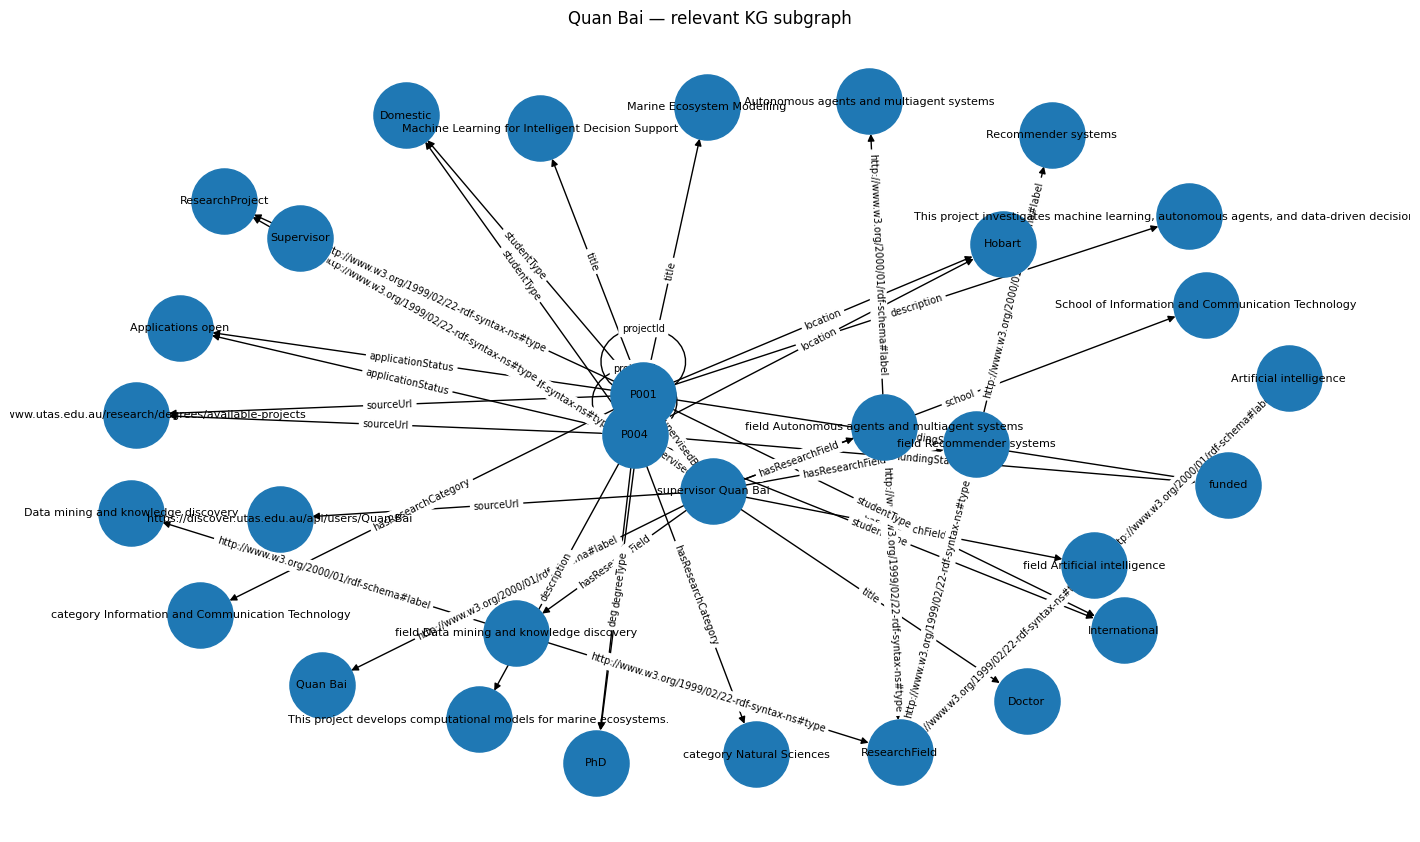

In [29]:
show_subgraph([find_supervisor_node('Quan Bai')], 'Quan Bai — relevant KG subgraph')

In [30]:
evidence_1=prepare_evidence(route_1)
pj('EVIDENCE',evidence_1)
generation_1=generate_answer(question_1,evidence_1)
pj('EVIDENCE CHECK',generation_1['guard'])
print('\nFINAL ANSWER\n------------\n'+generation_1['answer'])


EVIDENCE
--------
[
  {
    "source_id": "S1",
    "source_type": "knowledge_graph",
    "source": "Quan Bai",
    "source_url": "https://discover.utas.edu.au/api/users/Quan.Bai",
    "text": "{\"name\": \"Quan Bai\", \"title\": \"Doctor\", \"school\": \"School of Information and Communication Technology\", \"research_fields\": [\"Artificial intelligence\", \"Autonomous agents and multiagent systems\", \"Data mining and knowledge discovery\", \"Recommender systems\"], \"projects\": [[\"P001\", \"Machine Learning for Intelligent Decision Support\"], [\"P004\", \"Marine Ecosystem Modelling\"]], \"source_url\": \"https://discover.utas.edu.au/api/users/Quan.Bai\"}"
  }
]

EVIDENCE CHECK
--------------
{
  "passed": true,
  "question_terms": [
    "bai",
    "quan"
  ],
  "supported_terms": [
    "bai",
    "quan"
  ],
  "threshold": 2
}

FINAL ANSWER
------------
Quan Bai is a Doctor in the School of Information and Communication Technology, with research interests in Artificial intellige

# Manual cell-by-cell demo 2 — `What English score do I need for a PhD?`

In [31]:
question_2='What English score do I need for a PhD?'
trace_plan_2=interpret_question(question_2)
pj('STRUCTURED PLAN',trace_plan_2['plan'])


STRUCTURED PLAN
---------------
{
  "method": "retrieval",
  "scope": "general",
  "search_query": "English score for PhD",
  "degree_type": "PhD",
  "student_type": "general",
  "funding_status": null,
  "research_category": "English",
  "supervisor": null,
  "graph_operation": "retrieval",
  "intent": "find the required score",
  "confidence": 50,
  "planner_method": "qwen"
}


In [32]:
route_2=execute_route(question_2,trace_plan_2['plan'])
show_retrieval_trace(route_2['retrieval_trace'])


RETRIEVAL INPUT
---------------
{
  "scope": "general",
  "candidate_project_ids": null,
  "bm25_query_tokens": [
    "english",
    "score",
    "for",
    "phd"
  ]
}

BM25 RANKING
------------
[
  {
    "rank": 1,
    "id": "G002",
    "source": "English Language Requirements",
    "score": 3.965241388291684
  },
  {
    "rank": 2,
    "id": "G001",
    "source": "HDR Entry Requirements",
    "score": 0.9434292617614057
  },
  {
    "rank": 3,
    "id": "G003",
    "source": "Research Degree Funding",
    "score": 0.0
  }
]

MINILM SEMANTIC RANKING
-----------------------
[
  {
    "rank": 1,
    "id": "G002",
    "source": "English Language Requirements",
    "score": 0.6040105819702148
  },
  {
    "rank": 2,
    "id": "G001",
    "source": "HDR Entry Requirements",
    "score": 0.28981813788414
  },
  {
    "rank": 3,
    "id": "G003",
    "source": "Research Degree Funding",
    "score": 0.11036472022533417
  }
]

RRF HYBRID RESULTS
------------------
[
  {
    "document_id": "

In [33]:
evidence_2=prepare_evidence(route_2)
pj('EVIDENCE',evidence_2)
generation_2=generate_answer(question_2,evidence_2)
pj('EVIDENCE CHECK',generation_2['guard'])
print('\nFINAL ANSWER\n------------\n'+generation_2['answer'])


EVIDENCE
--------
[
  {
    "source_id": "S1",
    "source_type": "retrieved_text",
    "source": "English Language Requirements",
    "source_url": "https://www.utas.edu.au/study/apply/admission-requirements/english-language-requirements",
    "project_id": null,
    "text": "Applicants for a PhD must satisfy the University's English language requirements before commencing the research degree. This mini teaching snapshot does not contain an exact numerical score.",
    "bm25_score": 3.965241388291684,
    "semantic_score": 0.6040105819702148,
    "rrf_score": 0.03278688524590164
  },
  {
    "source_id": "S2",
    "source_type": "retrieved_text",
    "source": "HDR Entry Requirements",
    "source_url": "https://www.utas.edu.au/research/degrees",
    "project_id": null,
    "text": "Applicants for a PhD or other research degree must satisfy the academic entry requirements for the chosen program.",
    "bm25_score": 0.9434292617614057,
    "semantic_score": 0.28981813788414,
    "rrf_

# Manual cell-by-cell demo 3 — hybrid graph + retrieval

In [ ]:
question_3='Find funded international ICT PhD projects related to machine learning.'
trace_plan_3=interpret_question(question_3)
pj('STRUCTURED PLAN',trace_plan_3['plan'])

In [ ]:
route_3=execute_route(question_3,trace_plan_3['plan'])
show_graph_trace(route_3['graph_trace'])
pj('GRAPH-SELECTED PROJECT IDS',route_3['candidate_project_ids'])

In [ ]:
show_subgraph([UTAS[x] for x in route_3['candidate_project_ids']], 'Graph-selected candidate projects')

In [ ]:
show_retrieval_trace(route_3['retrieval_trace'])

In [ ]:
evidence_3=prepare_evidence(route_3)
pj('EVIDENCE',evidence_3)
generation_3=generate_answer(question_3,evidence_3)
pj('EVIDENCE CHECK',generation_3['guard'])
print('\nFINAL ANSWER\n------------\n'+generation_3['answer'])

# Central `ask()` function

This uses the **same functions** as the manual cells. It simply displays all stages in one call.

In [34]:
###Creating the End-to-End Traceable ask() Function

def ask(question, show_prompt=False, visualize_graph=True):
    print('='*88); print('STEP 1 — QUESTION'); print(question)
    interpreted=interpret_question(question)
    print('\n'+'='*88); print('STEP 2 — INTERPRETATION / STRUCTURED PLAN')
    if show_prompt: print(interpreted['prompt'])
    pj('PLAN',interpreted['plan'])
    route=execute_route(question,interpreted['plan'])
    print('\n'+'='*88); print('STEP 3 — EXECUTION ROUTE:',route['route'])
    if route.get('graph_trace'): show_graph_trace(route['graph_trace'])
    if route.get('candidate_project_ids') is not None: pj('GRAPH-SELECTED PROJECT IDS',route['candidate_project_ids'])
    if route.get('retrieval_trace'): show_retrieval_trace(route['retrieval_trace'])
    if visualize_graph:
        if route['route']=='graph' and interpreted['plan'].get('supervisor'):
            show_subgraph([find_supervisor_node(interpreted['plan']['supervisor'])], 'Relevant graph evidence')
        elif route['route']=='hybrid_graph':
            show_subgraph([UTAS[x] for x in route['candidate_project_ids']], 'Graph-selected candidates')
    evidence=prepare_evidence(route)
    print('\n'+'='*88); print('STEP 4 — COMMON EVIDENCE PACKAGE'); pj('EVIDENCE',evidence)
    generation=generate_answer(question,evidence)
    print('\n'+'='*88); print('STEP 5 — EVIDENCE SUPPORT CHECK'); pj('GUARD',generation['guard'])
    print('\n'+'='*88); print('STEP 6 — GROUNDED ANSWER PROMPT'); print(generation['prompt'])
    print('\n'+'='*88); print('STEP 7 — FINAL ANSWER'); print('Method:',generation['method']); print(generation['answer'])
    return {'interpretation':interpreted,'route':route,'evidence':evidence,'generation':generation}

In [ ]:
###Running the Full Graph Example
trace_1=ask('Who is Quan Bai?')

In [ ]:
###Running the Full Retrieval Example
trace_2=ask('What English score do I need for a PhD?')

STEP 1 — QUESTION
Find funded international ICT PhD projects related to machine learning.

STEP 2 — INTERPRETATION / STRUCTURED PLAN

PLAN
----
{
  "method": "hybrid_graph",
  "scope": "projects",
  "search_query": "machine learning, funded, international",
  "degree_type": "PhD",
  "student_type": "International",
  "funding_status": "funded",
  "research_category": "Information and Communication Technology",
  "supervisor": null,
  "graph_operation": "multi_constraint_projects",
  "intent": "find projects",
  "confidence": 1.0,
  "planner_method": "qwen"
}

STEP 3 — EXECUTION ROUTE: hybrid_graph

GRAPH INPUT
-----------
{
  "operation": "multi_constraint_projects",
  "function_called": "get_projects_by_constraints",
  "bindings": {
    "wantedDegree": "PhD",
    "wantedStudentType": "International",
    "wantedFunding": "funded",
    "wantedCategory": "Information and Communication Technology"
  }
}

EXACT CONTROLLED SPARQL
-----------------------
PREFIX utas: <https://example.org/ut

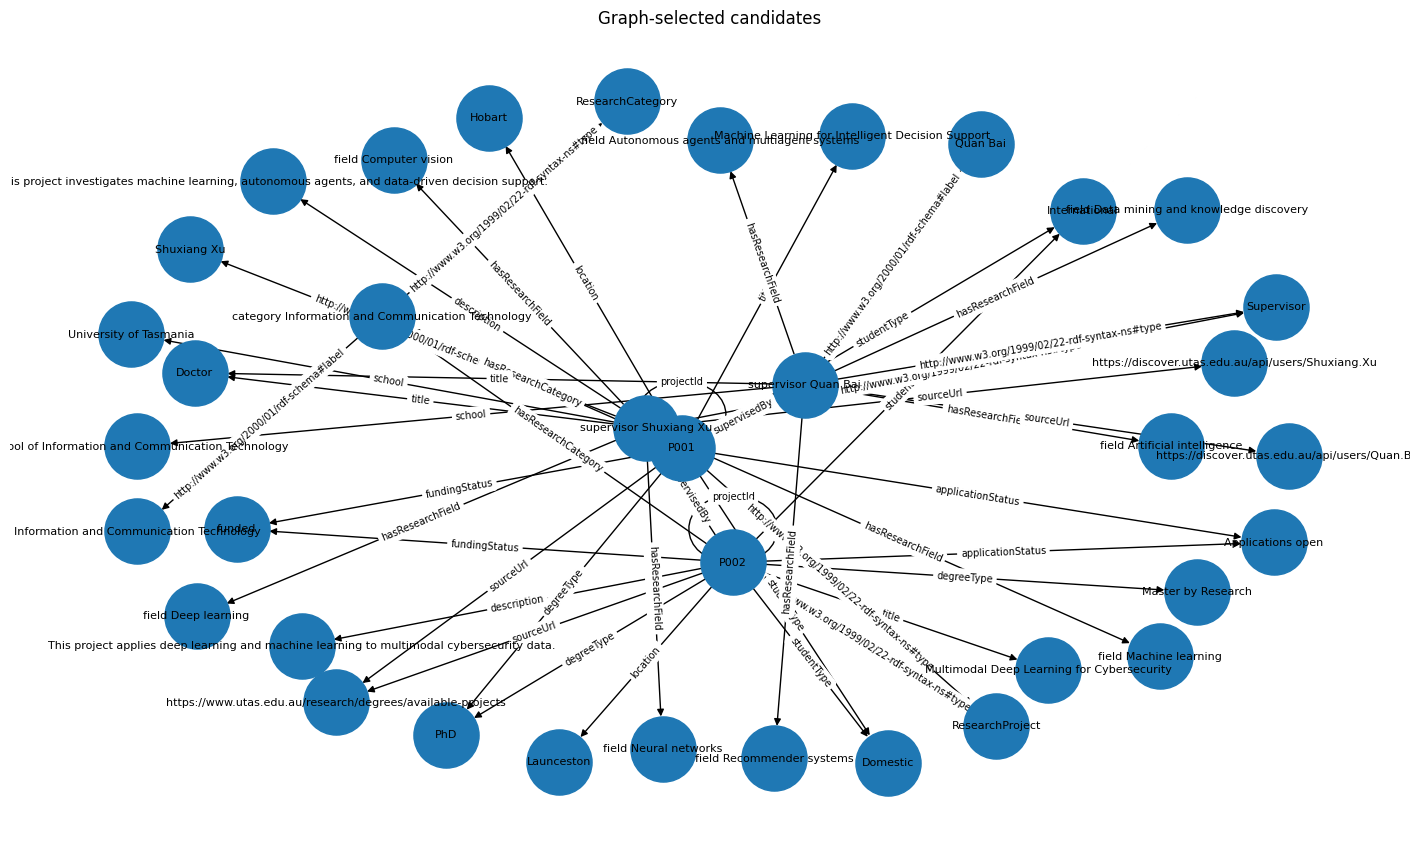


STEP 4 — COMMON EVIDENCE PACKAGE

EVIDENCE
--------
[
  {
    "source_id": "S1",
    "source_type": "retrieved_text",
    "source": "Machine Learning for Intelligent Decision Support",
    "source_url": "https://www.utas.edu.au/research/degrees/available-projects",
    "project_id": "P001",
    "text": "Machine Learning for Intelligent Decision Support This project investigates machine learning, autonomous agents, and data-driven decision support. PhD Domestic International funded Hobart Information and Communication Technology Quan Bai",
    "bm25_score": 1.9921728288123177,
    "semantic_score": 0.5397590398788452,
    "rrf_score": 0.03278688524590164
  },
  {
    "source_id": "S2",
    "source_type": "retrieved_text",
    "source": "Multimodal Deep Learning for Cybersecurity",
    "source_url": "https://www.utas.edu.au/research/degrees/available-projects",
    "project_id": "P002",
    "text": "Multimodal Deep Learning for Cybersecurity This project applies deep learning and machin

In [35]:
###Running the Full Hybrid Example
trace_3=ask('Find funded international ICT PhD projects related to machine learning.')

## Final mental model

**Question → Qwen/routing rules → structured instruction → graph/retrieval/hybrid execution → evidence → evidence check → grounded answer**
